# Using the SVO Filter Profile Service *'Carlos Rodrigo'*

This notebook demonstrates how to use the SVO Filter Profile Service (FPS) to explore and visualize astronomical filter transmission curves. It provides helper functions to query the FPS, retrieve filter metadata and transmission data, and plot the results. You will learn how to search for filters using different criteria, inspect filter properties, and visualize their transmission profiles using Python tools.

Before exploring the SVO Filter Profile Service, we will start by defining some helper functions to simplify querying and handling filter data.
Import the library and define some helper functions. 

The function `get_votable` helps getting the information from the FPS service in VOTable format.

- Parameters
    - query : dict  
        Used to create a HTTP query string i.e. send to SVO FPS to get data.
        In dictionary, specify keys as search parameters (str) and
        values as required. Description of search parameters can be found at
        <https://svo2.cab.inta-csic.es/theory/fps/index.php?mode=voservice>.

- Returns
    - votable as returned by the service


In [ ]:
# Imports
%pip install astroquery matplotlib

  Using cached matplotlib-3.10.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pillow-11.2.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.6 MB)
Using cached contourpy-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (323 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.5 MB/s eta 0:00:00
Using cached kiwisolver-1.4.8-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.5 MB)
Using cached pillow-11.2.1-cp312-cp

In [ ]:
import io
from astroquery.query import BaseQuery
from astropy.io.votable import parse_single_table
from astropy.io.votable.tree import TableElement
from astropy.table import Table
import matplotlib.pyplot as plt

In [5]:
def get_votable(query):
    query['FORMAT'] = 'votable'
    basequery = BaseQuery()
    response = basequery._request("GET", "https://svo2.cab.inta-csic.es/theory/fps/fps.php", params=query)
    response.raise_for_status()
    votable = io.BytesIO(response.content)
    try:
        return votable
    except IndexError:
        # If no table element found in VOTable
        raise IndexError("No table element found in VOTable response. ")


The function `get_filter` can be used to retrieve detailed information about a filter using its unique ID.

It returns two tables:
- **Metadata Table:** Contains key properties and descriptive information about the filter (e.g., name, facility, instrument, wavelength characteristics).
- **Transmission Curve Table:** Provides the filter's transmission profile, showing how transmission varies with wavelength.

Use this function to inspect both the filter's attributes and its spectral response.

In [6]:
def get_filter(filter_id):
    query = {'ID': filter_id, 'VERB': 3}
    votable = get_votable(query)
    
    table_element:TableElement = parse_single_table(votable)
    # Extract parameter atributes
    names = [p.name for p in table_element.params]
    values = [p.value for p in table_element.params]
    units = [p.unit for p in table_element.params]

    # Create table with parameters
    paramstable = Table([names, values, units], names=('name', 'value', 'unit'))

    # Convert the transmission data to an Astropy Table    
    transmission = table_element.to_table()
    
    return paramstable, transmission


The function `get_filter_list` is used to query the filter list. Query parameter is a dictionary where the next ones can be combined:

- `WavelengthRef` (range)  
- `WavelengthMean` (range)  
- `WavelengthEff` (range)  
- `WavelengthMin` (range)  
- `WavelengthMax` (range)  
- `WidthEff` (range)  
- `FWHM` (range)  
- `Instrument` (value)  
- `Facility` (value)  
- `PhotSystem` (value)  

You can use these parameters to filter your search. For range parameters, specify minimum and/or maximum values using keys like `'WavelengthEff_min'` and `'WavelengthEff_max'`. For value parameters, provide the exact string value. For example:

- `{'WavelengthEff_min': 10000, 'WavelengthEff_max': 15000}` — filters by effective wavelength range.
- `{'Facility': '2MASS'}` — filters by facility name.

Refer to the [SVO FPS documentation](http://svo2.cab.inta-csic.es/theory/fps/index.php?mode=voservice) for a full list and details.

In [7]:
def get_filter_list(query):
    #add format and verb to query
    query['FORMAT'] = 'votable'
    return parse_single_table(get_votable(query)).to_table()

This cell demonstrates how to search for astronomical filters whose effective wavelength (`WavelengthEff`) falls within the range of 10000 to 15000 Angstroms. By specifying these limits in the query, we retrieve only those filters that operate in this wavelength interval, allowing for targeted exploration of relevant filter profiles.

In [8]:
query = {'WavelengthEff_min': 10000, 'WavelengthEff_max': 15000}
list = get_filter_list(query)
list


FilterProfileService,filterID,WavelengthUnit,WavelengthUCD,PhotSystem,DetectorType,Band,Instrument,Facility,ProfileReference,CalibrationReference,Description,Comments,WavelengthRef,WavelengthMean,WavelengthEff,WavelengthMin,WavelengthMax,WidthEff,WavelengthCen,WavelengthPivot,WavelengthPeak,WavelengthPhot,FWHM,Fsun,PhotCalID,MagSys,ZeroPoint,ZeroPointUnit,Mag0,ZeroPointType,AsinhSoft,TrasmissionCurve
,,,,,,,,,,,,,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,erg / (A s cm2),,,Jy,,,,,
object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,object,float64,object,float64,object
ivo://svo/fps,Clementine/UVVIS.1000nm,Angstrom,em.wl,UVVIS,1,,UVVIS,Clementine,https://ui.adsabs.harvard.edu/abs/1994Sci...266.1835N/abstract,,Clementine UVVIS 1000nm filter,Digitized from Fig.3 in Nozette et al 1994.,10005.431349553,10006.525338972,10001.710350115,9794.7056066292,10192.343322709,257.26770706158,10010.157521459,10005.431349553,10007.276,10002.461075237,263.51606832407,72.935315110397,Clementine/UVVIS.1000nm/Vega,Vega,2049.9792459006,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=Clementine/UVVIS.1000nm
ivo://svo/fps,Selene/MI.NIR1,Angstrom,em.wl,MI,1,,MI,Selene,https://ui.adsabs.harvard.edu/abs/2010SSRv..154...79K/abstract,,SELENE MI NIR1 band,Digitized from Fig.5 in Kodama et al. 2010,10012.354137395,10013.355783209,10009.14368586,9818.1149108833,10192.307718782,268.35146377767,10013.771790356,10012.354137395,9976.4824,10009.829621025,276.10415486917,72.813510083483,Selene/MI.NIR1/Vega,Vega,2050.4131082611,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=Selene/MI.NIR1
ivo://svo/fps,Selene/MI.VIS5,Angstrom,em.wl,MI,1,,MI,Selene,https://ui.adsabs.harvard.edu/abs/2010SSRv..154...79K/abstract,,SELENE MI VIS5 band,Digitized from Fig.5 in Kodama et al. 2010,10013.990650006,10017.137424728,10008.826317709,9583.6457500746,10479.256333864,437.66208742361,10016.211513797,10013.990650006,10126.05,10010.973791205,419.49964886476,72.7392507578,Selene/MI.VIS5/Vega,Vega,2088.789872848,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=Selene/MI.VIS5
ivo://svo/fps,Cassini/ISS_WAC.IR4,Angstrom,em.wl,Cassini,1,,ISS_WAC,Cassini,https://pds-imaging.jpl.nasa.gov/documentation/ISS_Data_User_Guide_160929.pdf,,Cassini ISS WAC IR4 filter (full),,10023.469869414,10028.480615774,10016.565236672,9674.131626581,10570.0,334.89581295288,9939.1695240749,10023.469869414,9862.0,10019.881952791,269.95032829366,72.666013676653,Cassini/ISS_WAC.IR4/Vega,Vega,2105.0614862502,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=Cassini/ISS_WAC.IR4
ivo://svo/fps,Cassini/ISS_NAC.IR4,Angstrom,em.wl,Cassini,1,,ISS_NAC,Cassini,https://pds-imaging.jpl.nasa.gov/documentation/ISS_Data_User_Guide_160929.pdf,,Cassini ISS NAC IR4 filter (full),,10022.973432771,10028.530640795,10015.307288235,9644.1431418728,10564.680219458,406.50585750895,9959.3533175423,10022.973432771,9844.0,10018.997734016,370.01086302381,72.658327943089,Cassini/ISS_NAC.IR4/Vega,Vega,2106.7128945252,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=Cassini/ISS_NAC.IR4
ivo://svo/fps,LasCumbres/LasCumbres.PS_y,Angstrom,em.wl,PAN-STARRS,0,y,,LasCumbres,https://lco.global/observatory/filters/,,Las Cumbres Observatory PAN-Starrs y filter,,10023.095388272,10038.929318223,10007.764612728,9233.9857142857,10787.1375,1072.6493357629,10041.84374335,10023.095388272,10035.0,10018.299183456,1077.3361353479,72.492430150378,LasCumbres/LasCumbres.PS_y/Vega,Vega,2100.7698763483,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=LasCumbres/LasCumbres.PS_y
ivo://svo/fps,LBT/LUCIFER.Y1,Angstrom,em.wl,,0,,LUCIFER,LBT,http://abell.as.arizona.edu/~lbtsci/Instruments/LUCIFER/lucifer.html,,LUCIFER (1/2) Y1 filter,,10063.1277

To search for all filters belonging to a specific facility, you can specify the facility name in your query dictionary using the `'Facility'` key. This allows you to retrieve a list of all filters associated with that observatory or survey. For example, searching with `{'Facility': '2MASS'}` will return all filters from the 2MASS survey. This approach is useful when you want to explore or compare the filter profiles available for a particular instrument or facility.

In [9]:
query = {'Facility': '2MASS'}
filters_2mass = get_filter_list(query)
filters_2mass

FilterProfileService,filterID,WavelengthUnit,WavelengthUCD,PhotSystem,DetectorType,Band,Instrument,Facility,ProfileReference,CalibrationReference,Description,Comments,WavelengthRef,WavelengthMean,WavelengthEff,WavelengthMin,WavelengthMax,WidthEff,WavelengthCen,WavelengthPivot,WavelengthPeak,WavelengthPhot,FWHM,Fsun,PhotCalID,MagSys,ZeroPoint,ZeroPointUnit,Mag0,ZeroPointType,AsinhSoft,TrasmissionCurve
,,,,,,,,,,,,,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,Angstrom,erg / (A s cm2),,,Jy,,,,,
object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,object,float64,object,float64,object
ivo://svo/fps,2MASS/2MASS.J,Angstrom,em.wl,2MASS,0,J,,2MASS,http://www.ipac.caltech.edu/2mass/releases/allsky/doc/sec6_4a.html#rsr,http://adsabs.harvard.edu/abs/2003AJ....126.1090C,2MASS J,,12350.0,12350.0,12350.0,10806.470589792,14067.974683578,1624.3190191027,12390.584132888,12358.085272333,13260.0,12321.150081167,2149.144540383,45.893378329016,2MASS/2MASS.J/Vega,Vega,1594.0,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=2MASS/2MASS.J
ivo://svo/fps,2MASS/2MASS.H,Angstrom,em.wl,2MASS,0,H,,2MASS,http://www.ipac.caltech.edu/2mass/releases/allsky/doc/sec6_4a.html#rsr,http://adsabs.harvard.edu/abs/2003AJ....126.1090C,2MASS H,,16620.0,16620.0,16620.0,14787.378640179,18231.020407164,2509.4034987068,16487.192828097,16457.503740034,16710.0,16422.955724896,2609.6475383665,22.596337946016,2MASS/2MASS.H/Vega,Vega,1024.0,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=2MASS/2MASS.H
ivo://svo/fps,2MASS/2MASS.Ks,Angstrom,em.wl,2MASS,0,Ks,,2MASS,http://www.ipac.caltech.edu/2mass/releases/allsky/doc/sec6_4a.html#rsr,http://adsabs.harvard.edu/abs/2003AJ....126.1090C,2MASS Ks,,21590.0,21590.0,21590.0,19543.692304348,23552.400005256,2618.8695332218,21634.039848591,21603.094799742,22630.0,21557.652498909,2784.5527721703,8.794065776272,2MASS/2MASS.Ks/Vega,Vega,666.8,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=2MASS/2MASS.Ks


To retrieve detailed information about a specific astronomical filter, you can use its unique filter ID with the `get_filter` function. This function returns two tables: one containing metadata about the filter (such as its name, facility, instrument, wavelength properties, and other characteristics), and another containing the filter's transmission curve data (wavelength vs. transmission values). This allows you to both inspect the filter's properties and visualize how it transmits light across different wavelengths. This step is essential for understanding the behavior and suitability of a filter for your scientific application.

In [10]:
params, transmission = get_filter('2MASS/2MASS.H')
params


name,value,unit
str20,str70,object
FilterProfileService,ivo://svo/fps,None
filterID,2MASS/2MASS.H,None
WavelengthUnit,Angstrom,None
WavelengthUCD,em.wl,None
Description,2MASS H,None
PhotSystem,2MASS,None
DetectorType,0,None
Band,H,None
Facility,2MASS,None


In [11]:
transmission

Wavelength,Transmission
Angstrom,
float64,float64
12890.0,0.0
13150.0,0.0
13410.0,0.0
13680.0,0.0
13970.0,0.0
14180.0,0.0
14400.0,0.0005
14620.0,0.0027999999


To visualize the characteristics of a specific astronomical filter, we can plot its transmission curve. The transmission curve provides insight into the filter's passband and overall behavior. 

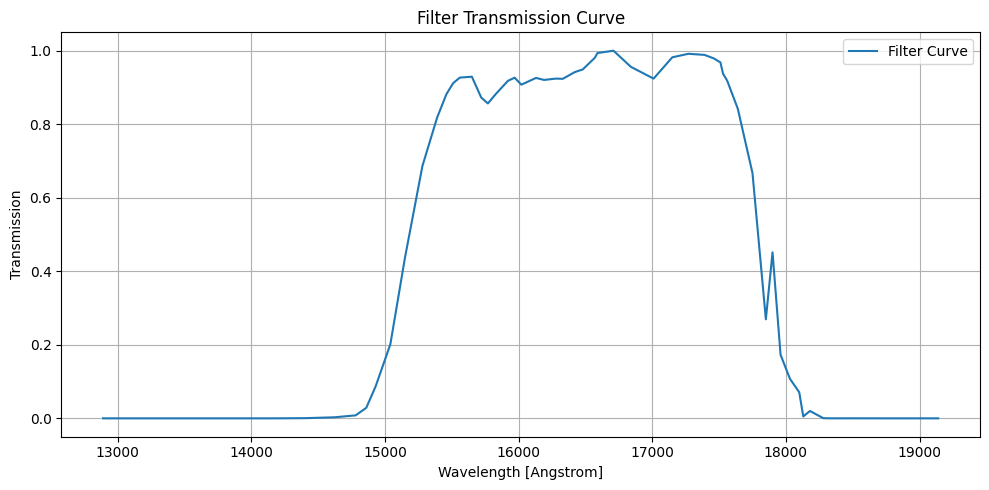

In [12]:
wl = transmission['Wavelength']
wl_unit = wl.unit
tr = transmission['Transmission']

plt.figure(figsize=(10, 5))
plt.plot(wl, tr, label='Filter Curve')
plt.xlabel(f'Wavelength [{wl_unit}]')
plt.ylabel('Transmission')
plt.title('Filter Transmission Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

To visualize and compare the transmission curves of all filters from a specific facility, you can iterate through the list of filters returned by your query and plot each filter's transmission profile on the same graph. This approach allows you to see the differences and overlaps between the filters, making it easier to understand their wavelength coverage and how they might be used together in observations. For example, by plotting all filters from the 2MASS facility, you can quickly assess the characteristics of each filter and their relative positions in the spectrum.

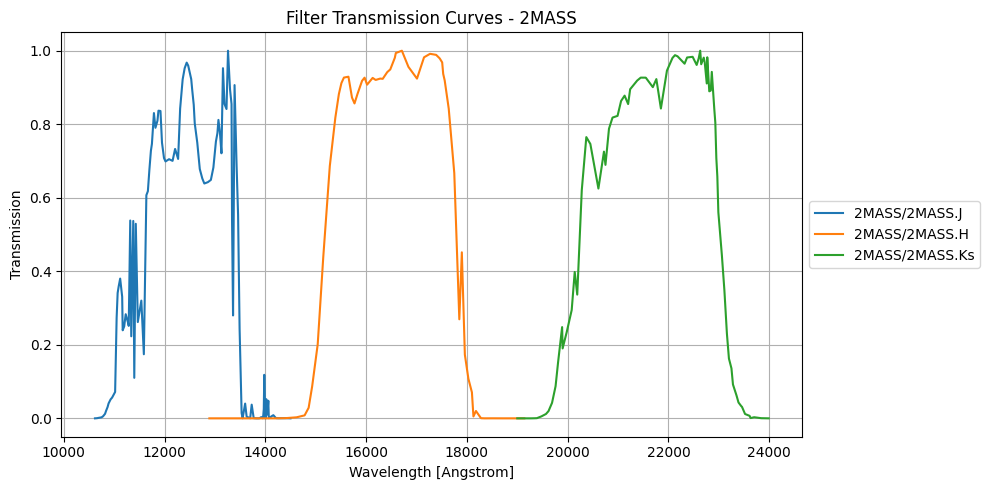

In [13]:

plt.figure(figsize=(10, 5))
plt.title('Filter Transmission Curves - 2MASS')
plt.grid(True)
plt.ylabel('Transmission')

wl_unit = None

for filt in filters_2mass:
    id = filt['filterID']
    filt_data, transmission = get_filter(id)

    wl = transmission['Wavelength']
    tr = transmission['Transmission']

    if wl_unit is None:
        wl_unit = wl.unit  # Assuming all filters have the same wavelength unit
    plt.plot(wl, tr, label=id)

plt.xlabel(f'Wavelength [{wl_unit}]')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()